# Controlled Trajectory Examples: 1 — Double Integrator

This is the **first example** in a four-part progression of controlled-trajectory
benchmarks built with `CellularSheaves.jl`:

1. **Double integrator** (this page) — the canonical first LQR system.
2. **Vehicle platoon** — same control story in a multi-agent / path-graph setting.
3. **Planar quadrotor** — a more realistic multi-input robotic system.
4. **Mass-spring-damper chain** — graph-coupled mechanical system bridging
   toward later consensus and network examples.

Each example follows the same conceptual pipeline:

$$
(A_c, B_c)
\;\longrightarrow\;
(A_d, B_d)
\;\longrightarrow\;
\mathcal{T}(x_1, x_{k+1})
\;\longrightarrow\;
\min_{z \in \mathcal{T}(x_1, x_{k+1})} J(z).
$$

## Physical system

A unit point mass moves along a line.  The state is position and velocity;
the control input is acceleration:

$$
x = \begin{bmatrix} p \\ \dot{p} \end{bmatrix}, \qquad u = a,
\qquad
A_c = \begin{bmatrix} 0 & 1 \\ 0 & 0 \end{bmatrix},
\qquad
B_c = \begin{bmatrix} 0 \\ 1 \end{bmatrix}.
$$

Despite its simplicity this system exhibits every feature of the
controlled-trajectory workflow and serves as the natural reference point for
the rest of the progression.

**References:**
- Anderson, B. D. O. & Moore, J. B. (1990). *Optimal Control: Linear Quadratic
  Methods*. Prentice-Hall.
- Lewis, F. L., Vrabie, D. L., & Syrmos, V. L. (2012). *Optimal Control*, 3rd ed.
  John Wiley & Sons. ISBN 978-0-470-63349-6.

In [1]:
using CellularSheaves
using LinearAlgebra
using BlockArrays
using Plots
using SparseArrays
using CellularSheaves.TrajectorySheaves

Import the API extension that provides `nullspace_trajectory_family`.

In [2]:
using CellularSheaves.TrajectorySheaves: nullspace_trajectory_family

## Step 1: Define the continuous-time model

The double integrator in standard state-space form.

In [3]:
Ac = [0.0  1.0;
      0.0  0.0]
Bc = reshape([0.0, 1.0], 2, 1)

2×1 Matrix{Float64}:
 0.0
 1.0

## Step 2: Discretize with zero-order hold

A `ControlledTrajectorySheaf` wraps the ZOH discretization
$x_{t+1} = A_d x_t + B_d u_t$ as a path-graph sheaf.  Its global
sections are exactly the feasible sampled state-control trajectories.

In [4]:
h = 0.25   # sample period (seconds)
k = 8      # number of time steps

F  = EuclideanSheaf{Float64}(fill(2, 1))   # base sheaf: one vertex, 2D stalk
ts = ControlledTrajectorySheaf(F, Ac, Bc, h, k)

println("State dimension  n = ", ts.state_dim)
println("Control dimension m = ", ts.control_dim)
println("Steps             k = ", ts.k)

State dimension  n = 2
Control dimension m = 1
Steps             k = 8


## Step 3: Fix endpoint states

We start at rest and aim to reach a target position with zero velocity.

In [5]:
x1  = [0.0, 0.0]   # initial state:  position 0, velocity 0
xk1 = [1.0, 0.0]   # terminal state: position 1, velocity 0

2-element Vector{Float64}:
 1.0
 0.0

## Step 4: Build the feasible trajectory affine space

`feasible_control_trajectory_basis` returns:
- `z_p` — a particular feasible trajectory (the harmonic extension of the
  boundary data);
- `N`   — columns spanning all endpoint-preserving perturbations.

Any feasible trajectory satisfies $z = z_p + N \alpha$ for some
$\alpha \in \mathbb{R}^r$.

In [6]:
z_p_raw, N = feasible_control_trajectory_basis(ts, x1, xk1)

n = ts.state_dim
m = ts.control_dim
r = size(N, 2)
println("Trajectory dimension p = ", (k+1)*n + k*m)
println("Free parameters      r = ", r)

Trajectory dimension p = 26
Free parameters      r = 6


Diagnose the conditioning of the sheaf Laplacian used in the harmonic extension.
The full Laplacian is singular by design because unconstrained global sections
lie in its nullspace, so its ordinary condition number is expected to be `Inf`.
The matrix that actually matters for the boundary-value solve is the interior
block `L_II` after fixing the two endpoint vertices.

In [7]:
L_full = sheaf_laplacian_matrix_direct(ts.sheaf)
σ_full = svdvals(Matrix(L_full))
σ_full_positive = filter(>(sqrt(eps(Float64))), σ_full)
boundary = Dict(1 => x1, k + 2 => xk1)
ldl_diag = harmonic_extension_ldl_diagnostics(ts.sheaf, boundary)
svd_diag = harmonic_extension_svd_diagnostics(ts.sheaf, boundary)
harmonic_extension_diagnostics = (
    full_cond=cond(Matrix(L_full)),
    full_positive_cond=isempty(σ_full_positive) ? Inf : maximum(σ_full_positive) / minimum(σ_full_positive),
    restricted_cond=svd_diag.condition_number,
    full_rank=size(σ_full_positive, 1),
    restricted_size=ldl_diag.restricted_size,
    restricted_zero_pivots=ldl_diag.nullity_estimate,
    restricted_smallest_positive_pivot=ldl_diag.smallest_positive_pivot,
    restricted_largest_zero_pivot=ldl_diag.largest_zero_pivot,
    restricted_pivot_gap=ldl_diag.pivot_gap,
    restricted_sorted_abs_pivots=ldl_diag.sorted_absolute_pivots,
    restricted_smallest_positive_singular_value=svd_diag.smallest_positive_singular_value,
    restricted_largest_small_singular_value=svd_diag.largest_small_singular_value,
    restricted_singular_value_gap=svd_diag.singular_value_gap,
)
harmonic_extension_diagnostics

(full_cond = 1.3201948043080755e19, full_positive_cond = 34.37734261591659, restricted_cond = 1.1352401339847588e18, full_rank = 18, restricted_size = (24, 24), restricted_zero_pivots = 4, restricted_smallest_positive_pivot = 0.000473484848484835, restricted_largest_zero_pivot = 0.0, restricted_pivot_gap = 1.0338842119766685e12, restricted_sorted_abs_pivots = [0.0, 0.0, 0.0, 0.0, 0.000473484848484835, 0.0012315270935960591, 0.03125, 0.03125, 0.09363295880149586, 0.988431281813975  …  1.0312499999999998, 1.0389423076923077, 1.0463917525773196, 1.4923076923076923, 1.9696969696969697, 1.9696969696969697, 2.0, 2.0, 2.0625, 2.0625], restricted_smallest_positive_singular_value = 0.010356247659305023, restricted_largest_small_singular_value = 3.26570394157487e-16, restricted_singular_value_gap = 1.0506943418052832e13)

## Step 5: Assemble the LQR objective

The conditioning diagnostic above helps distinguish two different effects:
the full sheaf Laplacian is singular for structural reasons, whereas the
restricted interior block `L_II` is the matrix actually inverted in the
harmonic extension step.

As in the scalar integrator example, a nonzero running state penalty `Q`
pulls the optimizer toward smaller intermediate states and can visibly squash
the trajectory. To emphasize the minimum-control-effort solution between fixed
endpoints, we set `Q = 0` here.

We therefore minimize the quadratic running cost

$$
J(z) = \tfrac{1}{2} \sum_{t=1}^{k}
  \bigl( x_t^\top Q\, x_t + u_t^\top R_u\, u_t \bigr)
  + \tfrac{1}{2}\, x_{k+1}^\top Q_f\, x_{k+1}.
$$

The assembled cost Hessian $H$ is block-diagonal: $k$ copies of $Q$
on the running state blocks, $Q_f$ on the terminal block, and $k$ copies
of $R_u$ on the control blocks. Because `x_{k+1}` is fixed as a hard
boundary condition, the `Q_f` term is constant over the feasible set and does
not affect the optimizer.

In [8]:
Q  = zeros(n, n)
Ru = Matrix{Float64}(I, m, m)
Qf = 0.0 * Matrix{Float64}(I, n, n)   # constant over the feasible set here

H, f, _ = lqr_objective(ts, Q, Ru; Qf=Qf)

(sparse([19, 20, 21, 22, 23, 24, 25, 26], [19, 20, 21, 22, 23, 24, 25, 26], [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0], 26, 26), [-0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0  …  -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0], 0.0)

Rows/columns are ordered: [x₁, x₂, …, x_{k+1}, u₁, …, u_k].
The state blocks (left upper) carry Q and Qf; the control blocks (lower right) carry Ru.

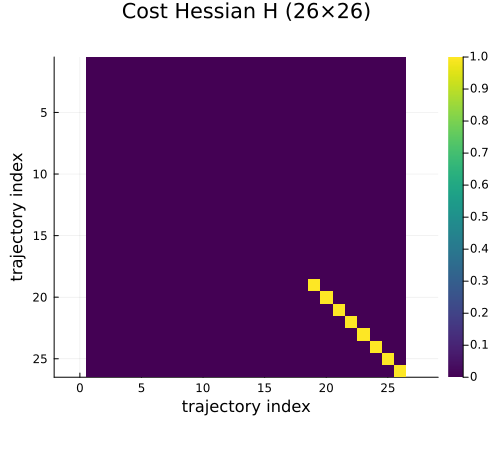

In [9]:
p_H = heatmap(Matrix(H);
    color=:viridis, colorbar=true,
    title="Cost Hessian H ($(size(H,1))×$(size(H,2)))",
    xlabel="trajectory index", ylabel="trajectory index",
    yflip=true, aspect_ratio=:equal, size=(500, 450))
p_H

## Step 6: Solve for the optimal feasible trajectory

`optimal_control_trajectory` restricts the quadratic objective to
the feasible affine space and solves the reduced quadratic programme

$$
\min_{\alpha} \tfrac{1}{2}\, \alpha^\top (N^\top H N)\, \alpha
  + \alpha^\top N^\top (H z_p + f).
$$

In [10]:
z_opt, α_opt, z_p_block, null_basis =
    optimal_control_trajectory(ts, x1, xk1, H, f)

([0.0, 0.0, 0.04166666666666707, 0.3333333333333338, 0.15476190476190485, 0.5714285714285716, 0.3154761904761904, 0.7142857142857152, 0.5000000000000002, 0.7619047619047624  …  1.0, 0.0, 1.3333333333333337, 0.9523809523809533, 0.5714285714285721, 0.1904761904761915, -0.19047619047619097, -0.5714285714285726, -0.9523809523809545, -1.3333333333333375], [-0.05683096163245982, -0.01998902210943276, 0.020241463739029852, 0.028801881193367438, -0.09039551498202329, 0.20404595623177837], [0.0, 0.0, 0.04039956395754063, 0.3231965116603223, 0.14930676160293588, 0.5480610695028426, 0.3037100987563258, 0.687165627724279, 0.48281393059584987, 0.7456650269919123  …  1.0, 0.0, 1.292786046641288, 0.8994582313700833, 0.5564182328857432, 0.23399759707053558, -0.09837706484502173, -0.4728056006466189, -0.9235908715920613, -1.4878865708839528], [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; -0.06811217598405372 -0.09471453470080479 … 0.07773527232161641 -0.21835476993060152; -0.04293200665000603 -0.013342252

Verify first-order optimality: the reduced gradient should vanish at α*.

In [11]:
Rred = null_basis' * H * null_basis
rred = null_basis' * (H * Array(z_p_block) + f)
println("Optimality residual ‖Rred α* + rred‖ = ", norm(Rred * α_opt + rred))

Optimality residual ‖Rred α* + rred‖ = 3.9557781533026204e-17


Verify that z_opt lies in the feasible affine space.

In [12]:
println("Affine-space error ‖z_opt − (z_p + N α*)‖ = ",
        norm(Array(z_opt) - (Array(z_p_block) + null_basis * α_opt)))

Affine-space error ‖z_opt − (z_p + N α*)‖ = 0.0


## Step 7: Plot only the optimal trajectory (reference view)

State blocks: `z_opt[Block(t)]` for `t = 1, …, k+1`.
Control blocks: `z_opt[Block(k+1+t)]` for `t = 1, …, k`.

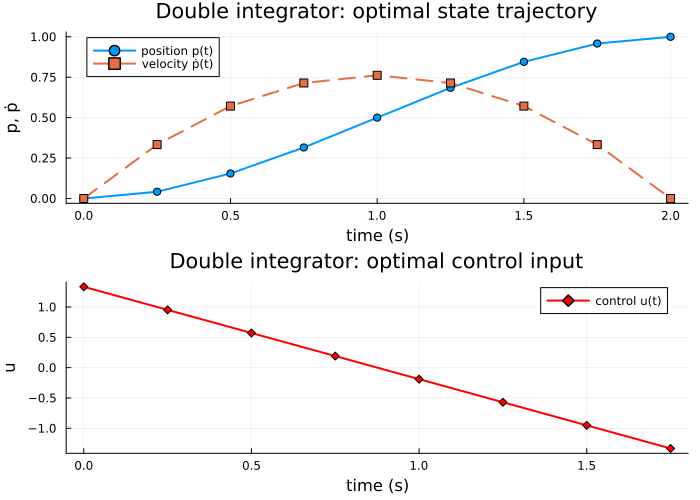

In [13]:
times_state   = h .* (0:k)
times_control = h .* (0:k-1)

positions  = [Array(z_opt[Block(t)])[1] for t in 1:k+1]
velocities = [Array(z_opt[Block(t)])[2] for t in 1:k+1]
controls   = [Array(z_opt[Block(k+1+t)])[1] for t in 1:k]

p_pos = plot(times_state, positions;
    lw=2, marker=:circle, label="position p(t)",
    xlabel="time (s)", ylabel="p, ṗ",
    title="Double integrator: optimal state trajectory")
plot!(p_pos, times_state, velocities;
    lw=2, marker=:square, linestyle=:dash, label="velocity ṗ(t)")

p_ctrl = plot(times_control, controls;
    lw=2, marker=:diamond, color=:red, label="control u(t)",
    xlabel="time (s)", ylabel="u",
    title="Double integrator: optimal control input")

di_plot = plot(p_pos, p_ctrl; layout=(2, 1), size=(700, 500))
di_plot

## Step 8: Spy plot of the nullspace basis matrix

The nullspace basis `null_basis` (size p × r) spans the feasible
perturbations around the optimal trajectory. A spy plot gives a quick visual
cue of its sparsity pattern, which can be useful for debugging or
understanding how many degrees of freedom are active.

The `Plots.spy` recipe works directly with this returned matrix.

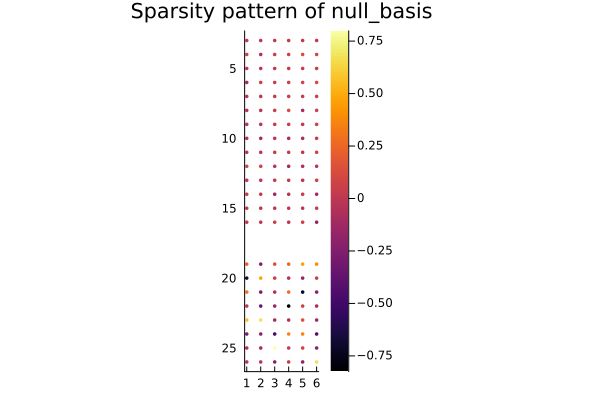

In [14]:
spy(null_basis, markersize=2, title="Sparsity pattern of null_basis")

## Verification (converted to warnings)

Endpoint checks – issue warnings instead of failing the build.

In [15]:
if !(Array(z_opt[Block(1)]) ≈ x1)
    @warn "Initial state not satisfied"
end
if !(Array(z_opt[Block(k + 1)]) ≈ xk1)
    @warn "Terminal state not satisfied"
end

Dynamics consistency – report any violations as warnings.

In [16]:
for t in 1:k
    xt  = Array(z_opt[Block(t)])
    xt1 = Array(z_opt[Block(t + 1)])
    ut  = Array(z_opt[Block(k + 1 + t)])
    resid = norm(ts.Ad * xt + ts.Bd * ut - xt1)
    if resid ≥ 1e-10
        @warn "Dynamics violated at step $t (residual = $resid)"
    end
end
println("All endpoint and dynamics checks completed (warnings, if any, were shown above).")

All endpoint and dynamics checks completed (warnings, if any, were shown above).


## Relationship to the sheaf boundary-value problem

The particular solution `z_p` is the **harmonic extension** of the boundary
data $(x_1, x_{k+1})$ to the full trajectory space.  It minimises the
sheaf Laplacian energy (i.e., the squared coboundary $\|dz\|^2$).

The null-basis columns $N_j$ are the *global sections of the controlled
sheaf* after zeroing the two boundary vertices — exactly the
endpoint-preserving degrees of freedom.

The optimal trajectory lives in the affine space $z_p + N\alpha^*$, where
$\alpha^*$ minimises the LQR cost restricted to that affine space.  The two
viewpoints — sheaf / harmonic-extension and quadratic / LQR — combine cleanly
because the feasible set is a finite-dimensional affine subspace.

## Step 9: Visualize the nullspace as a trajectory family

The spy plot in Step 8 revealed which rows of `null_basis` are non-zero,
showing the sparsity structure of the feasible perturbations.  Step 9 brings
those abstract columns to life: each one becomes a concrete state-control
trajectory that starts and ends at the prescribed boundary conditions.

Each nullspace basis vector gives one endpoint-preserving control mode.
We visualize the family members

$$
z^{(j)} = z_p + n_j
$$

where `n_j` is the `j`-th basis column scaled by `amplitude`.  These
trajectories are feasible but not generally optimal; the optimizer chooses a
linear combination of these directions that minimises the LQR cost.

In [17]:
family = nullspace_trajectory_family(ts, Array(z_p_block), null_basis; amplitude=3.0)

6-element Vector{BlockArrays.BlockVector{Float64, R} where R<:(AbstractVector{<:AbstractVector{Float64}})}:
 [0.0, 0.0, 0.06081465972816362, 0.4865172778253059, 0.1483042219210959, 0.21339921971815712, 0.24589776289509557, 0.5673491080738442, 0.3948674464539984, 0.6244083603973767  …  1.0, 0.0, 1.9460691113012212, -1.0924722324285927, 1.4157995534227459, 0.22823700929413404, 1.5743781131396164, -1.3274015643509347, -1.1279273995442225, -1.616682590833971]
 [0.0, 0.0, 0.017853527710250026, 0.1428282216819975, 0.12605663427817795, 0.722796630861428, 0.2987211446557063, 0.6585194521587978, 0.43889965673753184, 0.46290864449580815  …  1.0, 0.0, 0.571312886727989, 2.3198736367177224, -0.25710871481052266, -0.782443230651957, 1.9365924917079111, -1.0525792650855337, -1.2077344756944757, -1.527913328911139]
 [0.0, 0.0, 0.0529579096158478, 0.42366327692677996, 0.1922475451338831, 0.6906538072175061, 0.3778908308795148, 0.7944924787475506, 0.5703086180710875, 0.7448498187850292  …  1.0, 0.0, 1.

Plot the trajectories as perturbations of the optimal trajectory.

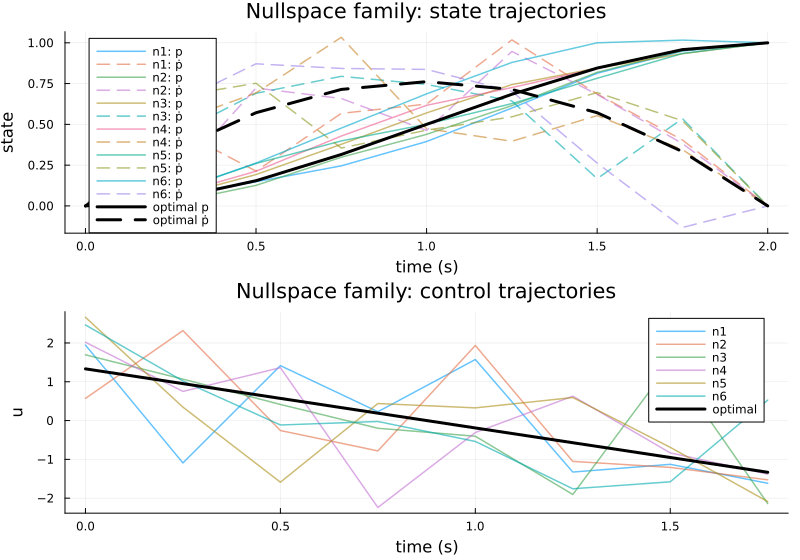

In [18]:
max_family = 8
if length(family) > max_family
    println("Plotting first $max_family of $(length(family)) basis trajectories.")
    family = family[1:max_family]
end


p_family_state = plot(
    xlabel="time (s)", ylabel="state",
    title="Nullspace family: state trajectories")
for (j, zf) in enumerate(family)
    pj = [Array(zf[Block(t)])[1] for t in 1:k+1]
    vj = [Array(zf[Block(t)])[2] for t in 1:k+1]
    plot!(p_family_state, times_state, pj; lw=1.5, alpha=0.6, label="n$(j): p")
    plot!(p_family_state, times_state, vj; lw=1.5, alpha=0.6, ls=:dash, label="n$(j): ṗ")
end
plot!(p_family_state, times_state, positions; lw=3, color=:black, label="optimal p")
plot!(p_family_state, times_state, velocities; lw=3, color=:black, ls=:dash, label="optimal ṗ")

p_family_ctrl = plot(
    xlabel="time (s)", ylabel="u",
    title="Nullspace family: control trajectories")
for (j, zf) in enumerate(family)
    uj = [Array(zf[Block(k+1+t)])[1] for t in 1:k]
    plot!(p_family_ctrl, times_control, uj; lw=1.5, alpha=0.6, label="n$(j)")
end
plot!(p_family_ctrl, times_control, controls; lw=3, color=:black, label="optimal")

family_plot = plot(p_family_state, p_family_ctrl; layout=(2, 1), size=(800, 560))
family_plot

## What this example establishes

The double integrator illustrates the complete pipeline in its simplest form.
Steps 8 and 9 together reveal two complementary views of the feasible
subspace: the spy plot (Step 8) shows the algebraic sparsity structure of the
null-basis matrix, while the trajectory family (Step 9) shows what those
basis directions look like as physical state-control trajectories.

The next example, **Vehicle Platoon**, keeps the same control story but
scales to a multi-agent setting by stacking two double integrators on a
two-vertex base sheaf, making the connection to network-structured problems
explicit for the first time.